# Análise exploratória da série temporal de tráfego do PTT/IX



Apresentação da análise exploratória da evolução do tráfego ao longo do tempo, olhando tanto para o crescimento de longo prazo quanto para padrões intra-anuais mais detalhados.

Explorar alguns pontos principais: uma tendência consistente de crescimento ao longo dos anos, ausência de uma ruptura estrutural clara em períodos específicos — como durante a pandemia — e a presença de padrões sazonais relativamente estáveis dentro de cada ano.

Um dos objetivos importantes dessa reunião é justamente validar esses achados com vocês. Como vocês têm uma visão mais próxima da operação e do contexto do sistema, quero entender se esses padrões estão alinhados com o que vocês esperariam teoricamente ou empiricamente — ou se existe algo aqui que chama atenção, surpreende, ou merece uma investigação mais aprofundada.

Então, mais do que só apresentar os resultados, a ideia é usar essa análise como base para discussão e refinamento conjunto das interpretações.





## 1. Importação de bibliotecas

In [3]:
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
import calendar



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Caminhos dos arquivos

Ajuste esta célula conforme a estrutura do seu projeto.

Se o notebook estiver em `monograph/notebooks` e a pasta `data` estiver em `monograph/data`, então `Path.cwd().parent` costuma ser suficiente.

In [4]:
base_dir = Path.cwd().parent  # ajuste se necessário

arquivo_xml = base_dir / "data" / "raw" / "ptt.xml"
saida_dir = base_dir / "data" / "processed"

arquivo_serie_csv = saida_dir / "serie_temporal_filtrada_gbps.csv"
arquivo_resumo_csv = saida_dir / "resumo_anual_filtrado_gbps.csv"
arquivo_weekday_csv = saida_dir / "resumo_weekday_gbps.csv"
arquivo_weekend_csv = saida_dir / "comparacao_weekend_gbps.csv"

saida_dir.mkdir(parents=True, exist_ok=True)

print("Base dir:", base_dir)
print("XML:", arquivo_xml)
print("Existe?", arquivo_xml.exists())
print("Saída:", saida_dir)

Base dir: /Users/cristiane/git/mba-ai-usp/monograph
XML: /Users/cristiane/git/mba-ai-usp/monograph/data/raw/ptt.xml
Existe? True
Saída: /Users/cristiane/git/mba-ai-usp/monograph/data/processed


## 3. Leitura do arquivo XML

In [5]:
tree = ET.parse(arquivo_xml)
root = tree.getroot()

step = int(root.find("step").text)
lastupdate = int(root.find("lastupdate").text)
rows = root.find("rra/database").findall("row")

print("step (segundos):", step)
print("lastupdate:", lastupdate)
print("número de linhas:", len(rows))

step (segundos): 300
lastupdate: 1768334849
número de linhas: 2100154


## 4. Funções auxiliares

In [7]:
def parse_valor(texto):
    if texto is None or texto == "NaN":
        return None
    return float(texto)

def medicoes_esperadas_no_ano(ano, passo_segundos=300):
    dias = 366 if calendar.isleap(ano) else 365
    return (24 * 60 * 60 // passo_segundos) * dias

## 5. Reconstrução da série temporal

Cada linha do XML possui dois valores (`v`), correspondentes aos fluxos de entrada e saída.

Neste notebook, a variável principal de análise será:

`total_bps = entrada + saída`

In [8]:
n = len(rows)
start_time = lastupdate - (n * step)

serie = []

for i, row in enumerate(rows):
    timestamp = start_time + i * step
    datahora = datetime.fromtimestamp(timestamp)

    vals = row.findall("v")

    v0 = parse_valor(vals[0].text) if len(vals) > 0 else None
    v1 = parse_valor(vals[1].text) if len(vals) > 1 else None

    total = None if (v0 is None or v1 is None) else (v0 + v1)

    serie.append((datahora, total))

df = pd.DataFrame(serie, columns=["datahora", "total_bps"])
df["datahora"] = pd.to_datetime(df["datahora"])
df["year"] = df["datahora"].dt.year

df.tail()

,datahora,total_bps,year
2100149,2026-01-13 16:42:29,5.380362e+12,2026
2100150,2026-01-13 16:47:29,5.376236e+12,2026
2100151,2026-01-13 16:52:29,5.377334e+12,2026
2100152,2026-01-13 16:57:29,5.382102e+12,2026
2100153,2026-01-13 17:02:29,5.370277e+12,2026


## 6. Verificação inicial

In [9]:
print(df.tail())
print()
print(df.info())
print()
print("Período coberto:")
print(df["datahora"].min(), "até", df["datahora"].max())
print()
print("NaN em total_bps:", df["total_bps"].isna().sum())

                   datahora     total_bps  year
2100149 2026-01-13 16:42:29  5.380362e+12  2026
2100150 2026-01-13 16:47:29  5.376236e+12  2026
2100151 2026-01-13 16:52:29  5.377334e+12  2026
2100152 2026-01-13 16:57:29  5.382102e+12  2026
2100153 2026-01-13 17:02:29  5.370277e+12  2026

<class 'pandas.DataFrame'>
RangeIndex: 2100154 entries, 0 to 2100153
Data columns (total 3 columns):
 #   Column     Dtype         
---  ------     -----         
 0   datahora   datetime64[us]
 1   total_bps  float64       
 2   year       int32         
dtypes: datetime64[us](1), float64(1), int32(1)
memory usage: 40.1 MB
None

Período coberto:
2006-01-26 13:17:29 até 2026-01-13 17:02:29

NaN em total_bps: 217539


## 7. Resumo de completude anual

A completude anual é calculada com base em `total_bps`, comparando o número esperado de medições com o número de valores ausentes.

In [10]:
resumo_completude = df.groupby("year").agg(
    total_linhas=("total_bps", "size"),
    n_na_total=("total_bps", lambda x: x.isna().sum())
)

resumo_completude["esperado"] = resumo_completude.index.map(medicoes_esperadas_no_ano)
resumo_completude["completude"] = 1 - (
    resumo_completude["n_na_total"] / resumo_completude["esperado"]
)

resumo_completude["completude"] = resumo_completude["completude"].round(3)

resumo_completude

,total_linhas,n_na_total,esperado,completude
year,,,,
2006,97761,97761,105120,0.070
2007,105120,105120,105120,0.000
2008,105408,2710,105408,0.974
2009,105120,0,105120,1.000
2010,105120,0,105120,1.000
2011,105120,378,105120,0.996
2012,105408,171,105408,0.998
2013,105120,29,105120,1.000
2014,105120,107,105120,0.999


## 8. Filtragem por completude


A filtragem por completude é importante para evitar que anos muito incompletos distorçam as análises de tendência e os resumos anuais.



In [11]:
anos_validos = resumo_completude.loc[resumo_completude["completude"] > 0.95].index

df_filtrado = df[df["year"].isin(anos_validos)].copy()

print("Anos válidos:", list(anos_validos))
print("Dimensão da base filtrada:", df_filtrado.shape)

Anos válidos: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Dimensão da base filtrada: (1897273, 3)


## 9. Conversão para Gbps

A partir deste ponto, todas as análises são feitas sobre os dados filtrados e expressas em **Gbps**.

In [12]:
df_filtrado["total_gbps"] = df_filtrado["total_bps"] / 1e9
df_filtrado.head()

,datahora,total_bps,year,total_gbps
202881,2008-01-01 00:02:29,NaN,2008,NaN
202882,2008-01-01 00:07:29,NaN,2008,NaN
202883,2008-01-01 00:12:29,NaN,2008,NaN
202884,2008-01-01 00:17:29,NaN,2008,NaN
202885,2008-01-01 00:22:29,NaN,2008,NaN


## 10. Resumo anual apenas dos dados filtrados

O resumo abaixo é calculado **somente após o filtro de completude** e usa exclusivamente o tráfego total.

In [13]:
resumo = df_filtrado.groupby("year").agg(
    total_linhas=("total_gbps", "size"),
    media_total_gbps=("total_gbps", "mean"),
    mediana_total_gbps=("total_gbps", "median"),
    min_total_gbps=("total_gbps", "min"),
    max_total_gbps=("total_gbps", "max")
)

cols_gbps = ["media_total_gbps", "mediana_total_gbps", "min_total_gbps", "max_total_gbps"]
resumo[cols_gbps] = resumo[cols_gbps].round(3)

resumo

,total_linhas,media_total_gbps,mediana_total_gbps,min_total_gbps,max_total_gbps
year,,,,,
2008,105408,0.631,0.549,0.000,5.579
2009,105120,1.299,1.145,0.000,8.949
2010,105120,3.405,3.105,0.000,16.776
2011,105120,6.586,6.884,0.624,18.824
2012,105408,13.250,14.047,0.092,1001.530
2013,105120,26.415,27.944,2.903,950.902
2014,105120,65.944,66.895,5.972,783.080
2015,105120,116.210,122.704,15.791,480.673
2016,105408,214.643,232.270,34.100,1006.100


## 11. Salvando os CSVs principais

In [14]:
df_filtrado.to_csv(arquivo_serie_csv, index=False)
resumo.to_csv(arquivo_resumo_csv)

print("Série filtrada salva em:", arquivo_serie_csv)
print("Resumo anual filtrado salvo em:", arquivo_resumo_csv)

Série filtrada salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/serie_temporal_filtrada_gbps.csv
Resumo anual filtrado salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_anual_filtrado_gbps.csv


## 12. Distribuição do Tráfego por ano


Para analisar a evolução do tráfego ao longo do tempo, foram construídos boxplots anuais da variável total_gbps. Cada ponto no gráfico representa uma observação individual do tráfego (isto é, uma medição em um determinado instante, não necessariamente agregada por dia).

Devido à forte assimetria dos dados e à presença de valores extremos, foi aplicada uma escala logarítmica no eixo vertical, permitindo melhor visualização das distribuições e comparação entre diferentes ordens de magnitude ao longo dos anos.

Ressalta-se que os dados referentes ao ano de 2026 estão disponíveis apenas até o dia 13 de janeiro, o que deve ser considerado na interpretação dos resultados para esse período.



In [16]:
df_filtrado["ano"] = df_filtrado["datahora"].dt.year

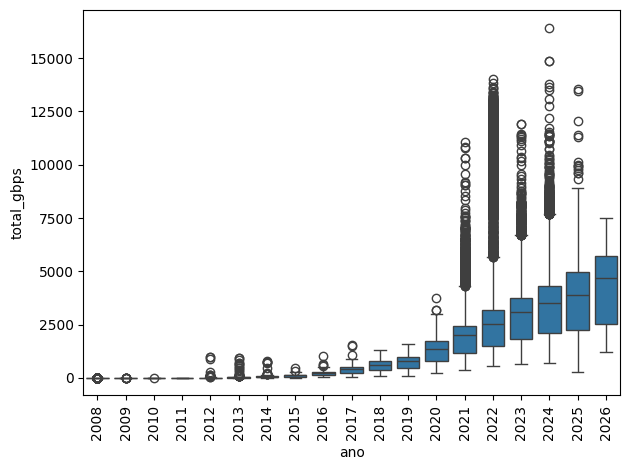

In [17]:
sns.boxplot(data=df_filtrado, x="ano", y="total_gbps")
plt.xticks(rotation=90)
plt.tight_layout()

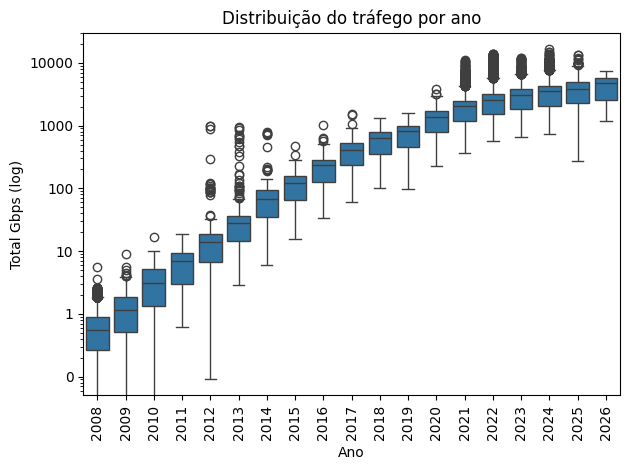

In [54]:
sns.boxplot(data=df_filtrado, x="ano", y="total_gbps")

plt.xticks(rotation=90)
plt.xlabel("Ano")
plt.ylabel("Total Gbps (log)")
plt.title("Distribuição do tráfego por ano")
plt.yscale("log")
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10))
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()

**Ao analisar a distribuição do tráfego em escala logarítmica, observa-se um crescimento aproximadamente exponencial ao longo dos anos, com sucessivas mudanças de ordem de grandeza.**


- ~1 Gbps (2008–2010)

- ~10–100 Gbps (2012–2015)

- ~100–1000 Gbps (2016–2019)

- ~1000–10000+ (2020+)

**A variabilidade do sistema se mantém proporcional ao nível de tráfego, indicando um comportamento multiplicativo típico de sistemas em expansão.**

- a “altura” das caixas é relativamente constante no log

- isso indica que a variabilidade é proporcional (multiplicativa)

Os eventos extremos acompanham esse crescimento, sugerindo que os picos de uso são consistentes com a evolução geral da rede.



## 13. Série temporal total com média diária e intervalo de confiança

Como a série original tem resolução de 5 minutos, é útil agregá-la por dia.

Para cada dia, serão calculados:

- média diária do tráfego total em Gbps;
- desvio padrão;
- número de observações;
- intervalo de confiança aproximado de 95%.

In [14]:
df_diario = df_filtrado.copy()
df_diario["data"] = df_diario["datahora"].dt.floor("D")

media_diaria = (
    df_diario.groupby("data")["total_gbps"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

media_diaria = media_diaria.rename(columns={
    "mean": "media_gbps",
    "std": "desvio_gbps",
    "count": "n_obs"
})

# manter apenas dias com ao menos 1 observação válida
media_diaria = media_diaria[media_diaria["n_obs"] > 0].copy()

media_diaria["ci_lower"] = (
    media_diaria["media_gbps"]
    - 1.96 * (media_diaria["desvio_gbps"] / np.sqrt(media_diaria["n_obs"]))
)
media_diaria["ci_upper"] = (
    media_diaria["media_gbps"]
    + 1.96 * (media_diaria["desvio_gbps"] / np.sqrt(media_diaria["n_obs"]))
)

media_diaria.head()

,data,media_gbps,desvio_gbps,n_obs,ci_lower,ci_upper
9,2008-01-10,0.233370,0.123246,170,0.214843,0.251897
10,2008-01-11,0.384466,0.208771,288,0.360354,0.408578
11,2008-01-12,0.351809,0.210455,288,0.327502,0.376115
12,2008-01-13,0.221142,0.093459,288,0.210348,0.231936
13,2008-01-14,0.238256,0.106753,288,0.225927,0.250586


## Plot da série temporal total: média diária + IC 95% em escala log



Aplicou-se a transformação logarítmica à média diária do tráfego (total_gbps) para lidar com a variação de escala ao longo do tempo. Em seguida, utilizou-se uma média móvel de 30 dias para suavizar a série e destacar a tendência.


Em escala logarítmica, a tendência aproximadamente linear indica crescimento proporcional contínuo ao longo do tempo. Não se observa ruptura clara em 2020, sugerindo continuidade da trajetória de crescimento. Valores negativos no início da série são esperados e correspondem a médias diárias inferiores a 1 Gbps.



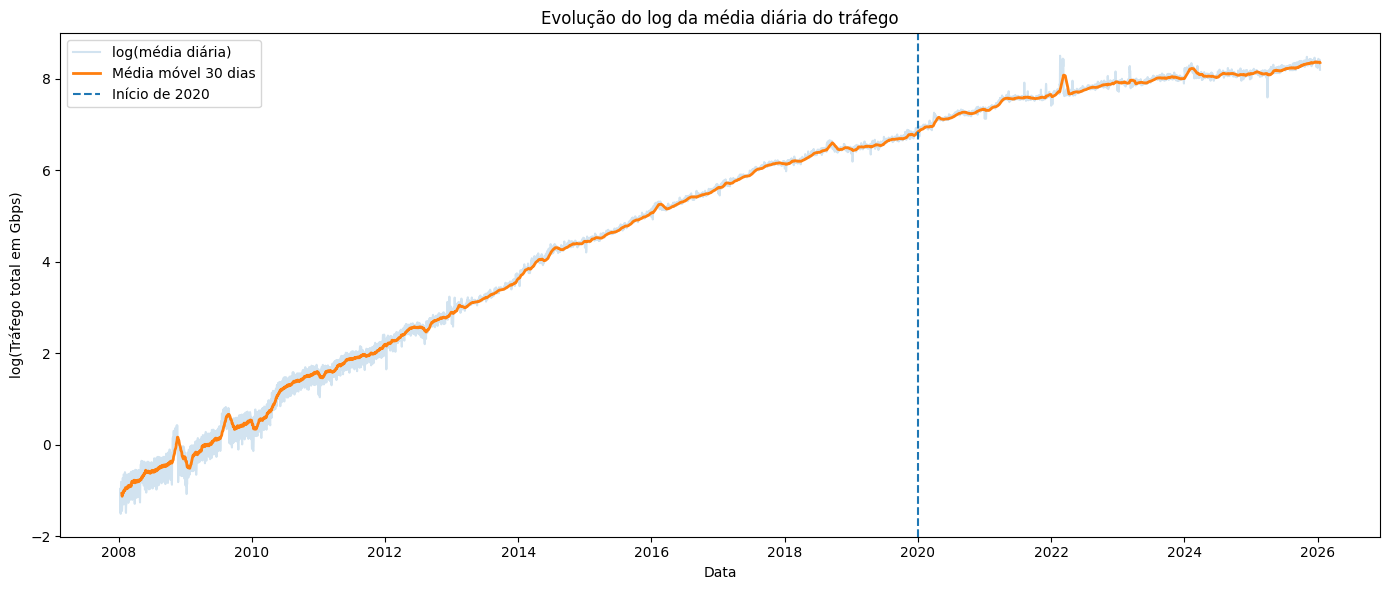

In [ ]:
df_log = media_diaria.copy()
df_log = df_log[df_log["media_gbps"] > 0].copy()
df_log["log_media"] = np.log(df_log["media_gbps"])
df_log["log_mm30"] = df_log["log_media"].rolling(30, min_periods=10).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_log["data"], df_log["log_media"], alpha=0.2, label="log(média diária)")
plt.plot(df_log["data"], df_log["log_mm30"], linewidth=2, label="Média móvel 30 dias")
plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--", linewidth=1.5, label="Início de 2020")

plt.xlabel("Data")
plt.ylabel("log(Tráfego total em Gbps)")
plt.title("Evolução do log da média diária do tráfego")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Evolução intra-anual com média diária em Gbps


Para complementar a análise da tendência global, foi construída uma visualização da média diária ao longo do ano, agrupando os anos em blocos de cinco. Esse gráfico permite comparar o comportamento intra-anual do tráfego entre diferentes períodos, destacando padrões sazonais e diferenças no nível médio, sem explicitar o intervalo de confiança

Para comparar o comportamento intra-anual do tráfego independentemente da escala, as séries foram normalizadas pelo valor médio de cada ano. Essa abordagem permite identificar padrões sazonais e avaliar a consistência do formato da série ao longo do tempo.

### Resultados

**Existe uma forte componente sazonal de curto prazo no tráfego.**

**Presença clara de sazonalidade de alta frequência, principalmente nos anos antigos**

- padrão “serrilhado” bem regular
- oscilações frequentes e repetitivas

Isso é típico de: ciclo semanal (dias úteis vs fim de semana)

**Redução do padrão serrilhado nos anos mais recentes**

Nos anos mais recentes (2023–2026):

- curvas mais suaves
- menos variação relativa

Possíveis interpretações:

- uso mais contínuo da rede
- menor diferença entre dias úteis e fins de semana
- sistema mais “estável” em termos relativos


**Eventos atípicos (outliers)**

Alguns exemplos visíveis:

2022 → picos muito altos no início do ano

2023–2026 → quedas/picos isolados

2025 → queda forte pontual

Possível interpretação:

existem eventos específicos que fogem do padrão sazonal, possivelmente relacionados a fatores operacionais ou externos.

A análise da série intra-anual normalizada evidencia um padrão consistente de crescimento do tráfego ao longo do ano, presente em todo o período analisado. Observa-se ainda uma forte componente sazonal de curto prazo, com oscilações regulares, especialmente nos anos iniciais. A semelhança das curvas entre diferentes anos indica que esse comportamento é estrutural e persistente ao longo do tempo, independentemente do nível absoluto de tráfego.


In [18]:
df_plot = df_filtrado.copy()
df_plot["dia_ano"] = df_plot["datahora"].dt.dayofyear

media_intra_anual = (
    df_plot.groupby(["year", "dia_ano"])["total_gbps"]
    .mean()
    .reset_index()
)

media_intra_anual.tail()

,year,dia_ano,total_gbps
6583,2026,9,4307.056469
6584,2026,10,4305.593678
6585,2026,11,4499.113847
6586,2026,12,4368.078070
6587,2026,13,3615.890195


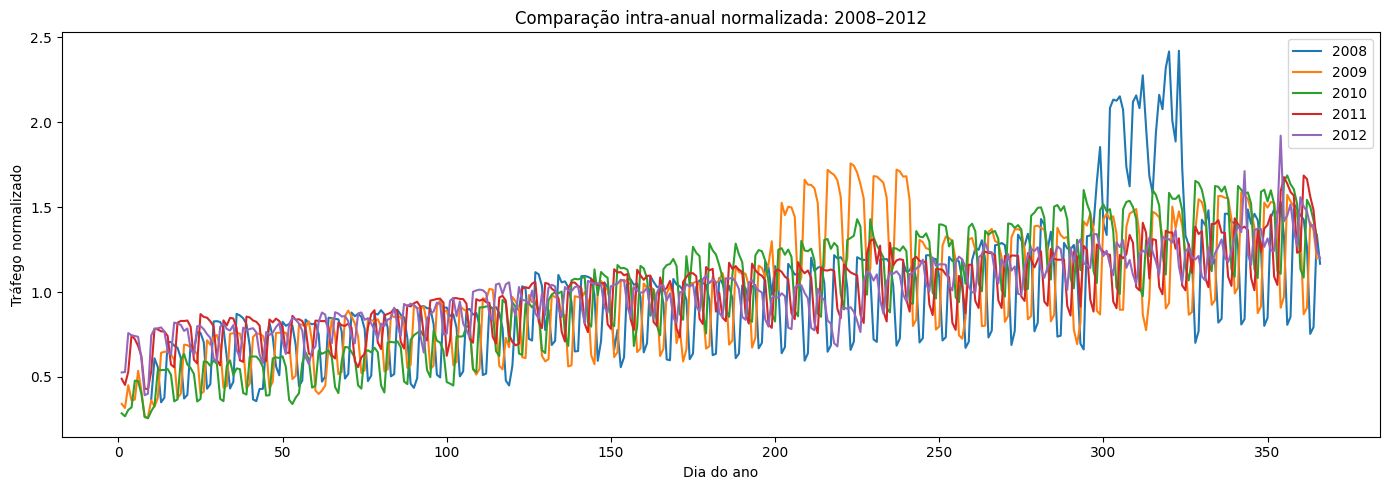

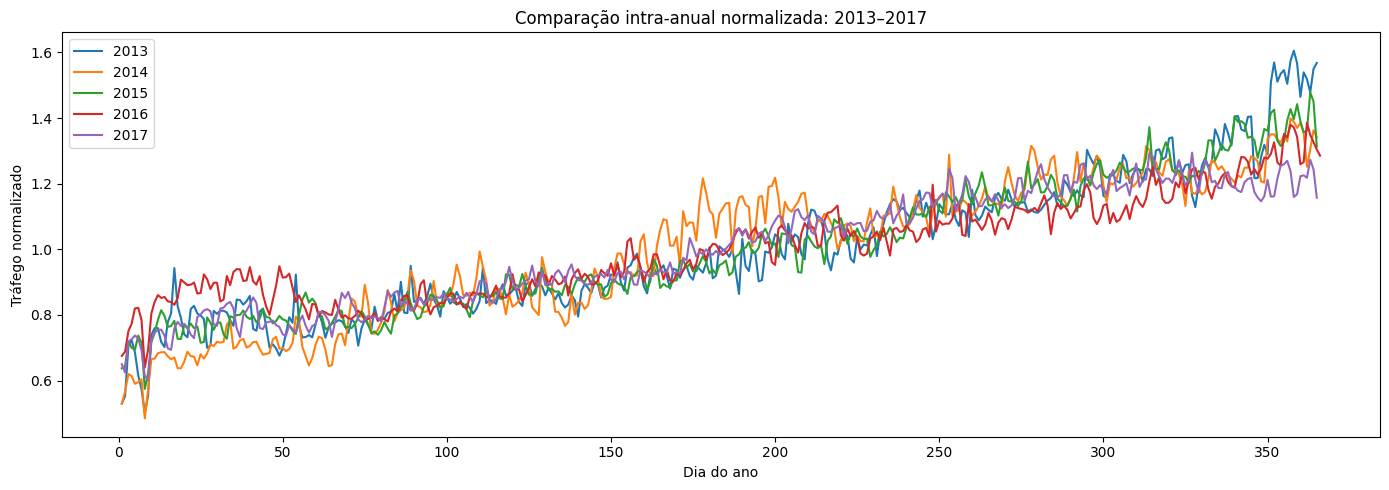

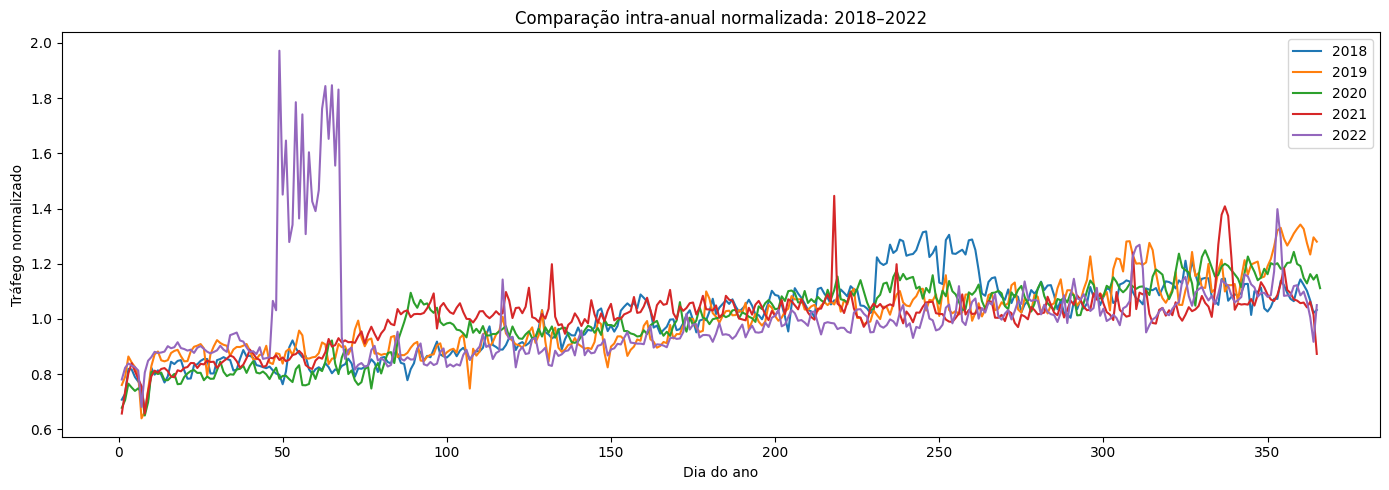

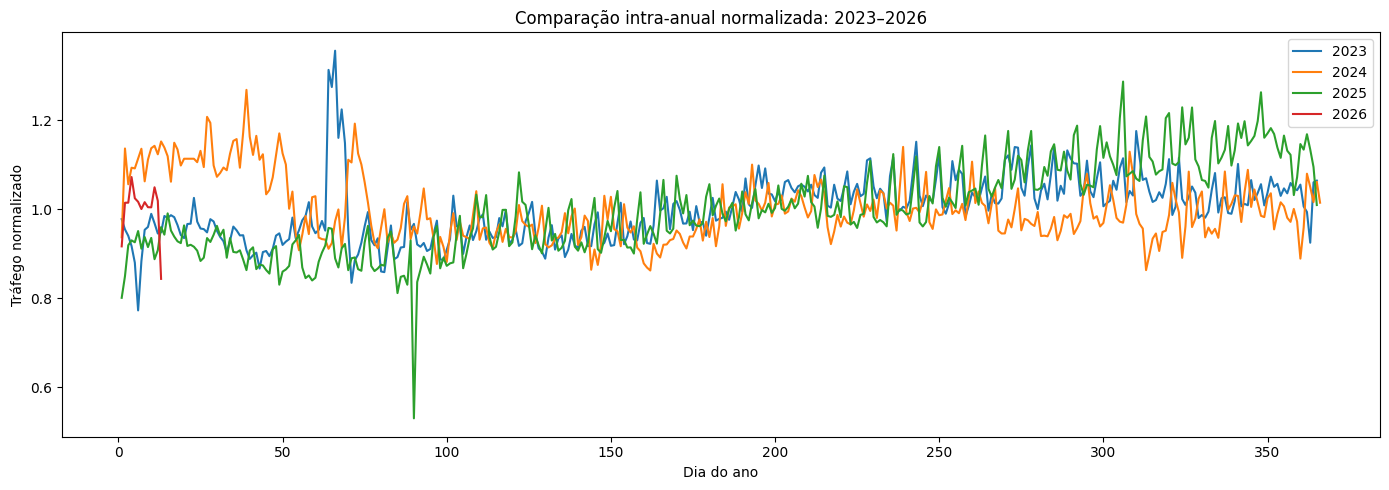

In [56]:
media_intra_anual["total_norm"] = (
    media_intra_anual.groupby("year")["total_gbps"]
    .transform(lambda x: x / x.mean())
)

anos = sorted(media_intra_anual["year"].unique())
blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(14, 5))
    
    for ano in bloco:
        grupo = media_intra_anual[media_intra_anual["year"] == ano]
        plt.plot(grupo["dia_ano"], grupo["total_norm"], label=str(ano))
    
    plt.xlabel("Dia do ano")
    plt.ylabel("Tráfego normalizado")
    plt.title(f"Comparação intra-anual normalizada: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 16. Análise por dia da semana

Agora a análise passa a considerar o comportamento do tráfego total ao longo da semana, usando apenas os dados filtrados.

In [18]:
df_filtrado["weekday"] = df_filtrado["datahora"].dt.weekday

mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

resumo_weekday_total = (
    df_filtrado.groupby("weekday")["total_gbps"]
    .mean()
    .reset_index(name="media_total_gbps")
)

resumo_weekday_total["dia"] = resumo_weekday_total["weekday"].map(mapa_dias)
resumo_weekday_total["media_total_gbps"] = resumo_weekday_total["media_total_gbps"].round(3)

resumo_weekday_total

,weekday,media_total_gbps,dia
0,0,988.636,Seg
1,1,980.817,Ter
2,2,982.819,Qua
3,3,987.595,Qui
4,4,981.509,Sex
5,5,985.606,Sáb
6,6,1000.453,Dom


### Observação metodológica

A média agregada de todos os anos pode ser enviesada, porque os anos mais recentes têm nível de tráfego muito maior que os anos antigos. Por isso, além do resumo geral, também é útil comparar o padrão semanal por blocos temporais.

## 17. Padrão semanal por blocos de anos

In [19]:
for bloco in [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]:
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")
    media["dia"] = media["weekday"].map(mapa_dias)
    media["media_total_gbps"] = media["media_total_gbps"].round(3)

    print(f"\nPeríodo {bloco}:")
    print(media[["weekday", "dia", "media_total_gbps"]])


Período (2008, 2012):
   weekday  dia  media_total_gbps
0        0  Seg             4.160
1        1  Ter             5.430
2        2  Qua             5.430
3        3  Qui             5.402
4        4  Sex             5.366
5        5  Sáb             5.277
6        6  Dom             4.326

Período (2013, 2017):
   weekday  dia  media_total_gbps
0        0  Seg           159.877
1        1  Ter           160.722
2        2  Qua           161.500
3        3  Qui           162.075
4        4  Sex           162.672
5        5  Sáb           163.739
6        6  Dom           162.505

Período (2018, 2022):
   weekday  dia  media_total_gbps
0        0  Seg          1398.496
1        1  Ter          1394.796
2        2  Qua          1400.202
3        3  Qui          1393.564
4        4  Sex          1412.419
5        5  Sáb          1404.211
6        6  Dom          1400.817

Período (2023, 2026):
   weekday  dia  media_total_gbps
0        0  Seg          3328.940
1        1  Ter         

## 18. Plot do padrão semanal 


Mudança estrutural clara ao longo do tempo

 - 2008–2012 (super evidente)

padrão clássico:

dias úteis acima da média (~1.1–1.15)

segunda e domingo bem abaixo (~0.7–0.8)

forte diferença entre dias úteis e fim de semana, uso concentrado em dias úteis

 - 2013–2017 (transição)

curvas praticamente flat (~1)

diferença entre dias diminui muito

sistema começa a se tornar mais homogêneo ao longo da semana

- 2018–2022 (estável e homogêneo)

linhas quase totalmente planas
todos os dias muito próximos de 1

padrão semanal praticamente desaparece, uso distribuído ao longo da semana

- 2023–2026 (novo padrão leve)

ainda homogêneo

pequenas variações:
leve queda terça/quinta em alguns anos
domingo até acima da média em alguns casos

possível leve reestruturação, mas sem voltar ao padrão antigo



**o sistema saiu de um comportamento “batch/horário comercial para um comportamento contínuo**

Possível explicação:

consumo digital mais constante
streaming / cloud / mobile
mudança de hábitos de consumo


In [21]:
df_filtrado["total_norm"] = (
    df_filtrado.groupby("year")["total_gbps"]
    .transform(lambda x: x / x.mean())
)

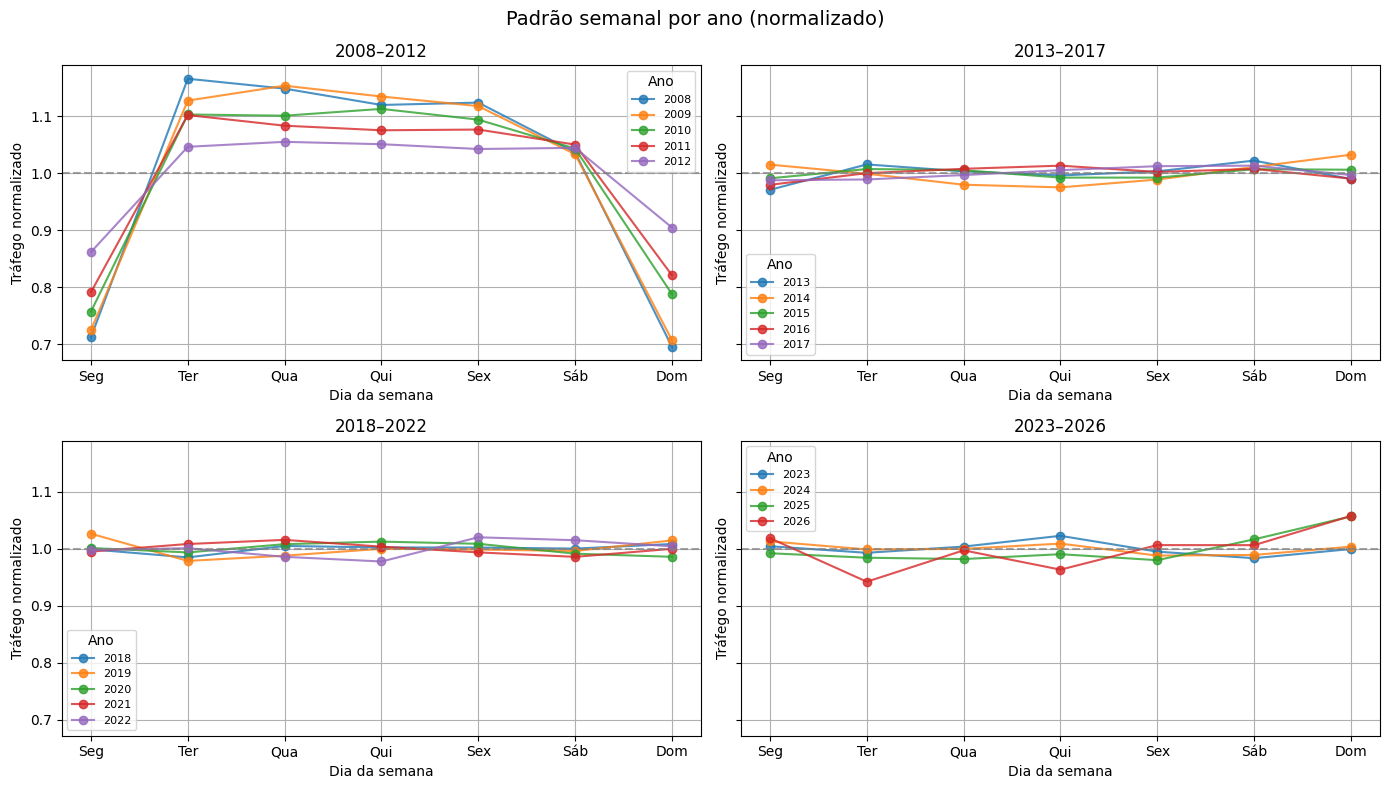

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    # média por ANO e dia da semana
    media_ano = (
        df_temp.groupby(["year", "weekday"])["total_norm"]
        .mean()
        .reset_index()
    )

    # plotar uma linha por ano
    for ano in sorted(media_ano["year"].unique()):
        grupo = media_ano[media_ano["year"] == ano]
        ax.plot(
            grupo["weekday"],
            grupo["total_norm"],
            marker="o",
            label=str(ano),
            alpha=0.8
        )

    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"{bloco[0]}–{bloco[-1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Tráfego normalizado")
    ax.axhline(1, linestyle="--", color="gray", alpha=0.7)
    ax.grid(True)

    ax.legend(title="Ano", fontsize=8)

plt.suptitle("Padrão semanal por ano (normalizado)", fontsize=14)
plt.tight_layout()
plt.show()

## 21. Salvando os resumos de weekday e fim de semana

In [22]:
resumo_weekday_total.to_csv(arquivo_weekday_csv, index=False)
comparacao_weekend_pivot.to_csv(arquivo_weekend_csv)

print("Resumo por dia da semana salvo em:", arquivo_weekday_csv)
print("Comparação dias úteis vs fim de semana salva em:", arquivo_weekend_csv)

Resumo por dia da semana salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_weekday_gbps.csv
Comparação dias úteis vs fim de semana salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/comparacao_weekend_gbps.csv


# Próximos passos

Como continuidade desta análise exploratória, algumas extensões podem aprofundar a compreensão dos padrões observados:

- realização de comparações formais entre períodos, por meio de testes estatísticos ou modelos apropriados, para avaliar a significância das diferenças identificadas;

- decomposição da série temporal em componentes de tendência, sazonalidade e resíduo, permitindo isolar e quantificar esses efeitos;

- aprofundamento da análise intra-semana e intra-dia, buscando caracterizar com maior granularidade os padrões de uso;

- identificação de possíveis pontos de mudança estrutural na série, para investigar alterações no comportamento ao longo do tempo;

- avaliação e tratamento de valores atípicos ou suspeitos, de modo a garantir a robustez das conclusões.

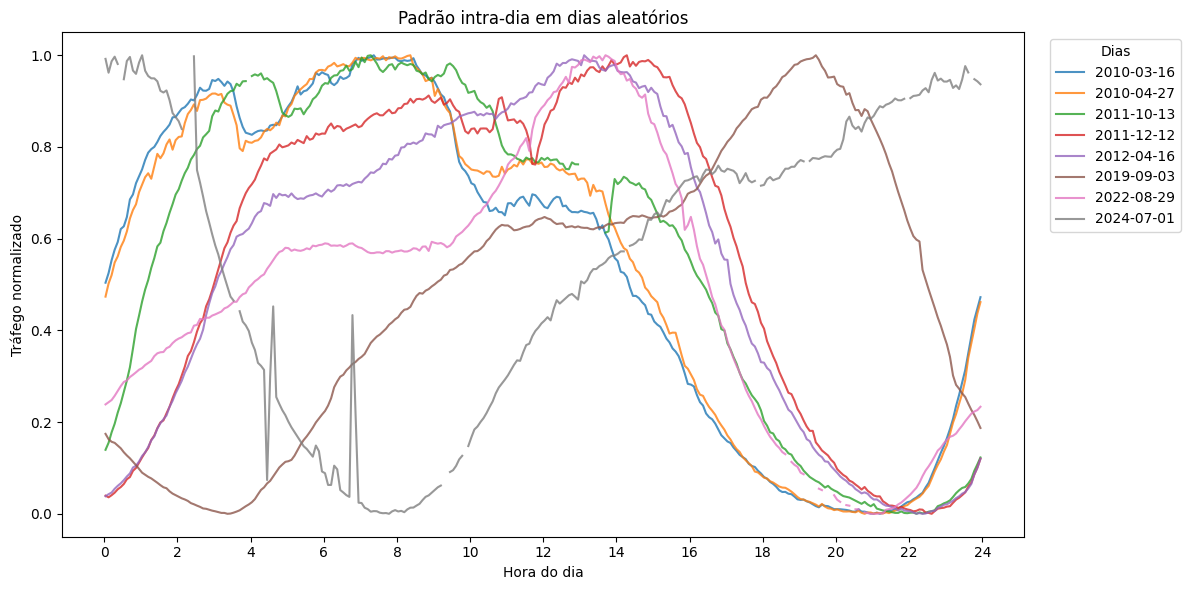

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# cópia da base
df_intradia = df_filtrado.copy()

# criar coluna de data e horário
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_min"] = df_intradia["datahora"].dt.hour * 60 + df_intradia["datahora"].dt.minute

# manter apenas dias completos (288 medições de 5 em 5 min)
contagem_por_dia = df_intradia.groupby("data").size()
dias_completos = contagem_por_dia[contagem_por_dia == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# sortear alguns dias aleatórios
np.random.seed(42)
n_dias = 8
dias_sorteados = np.random.choice(df_intradia["data"].unique(), size=n_dias, replace=False)

df_amostra = df_intradia[df_intradia["data"].isin(dias_sorteados)].copy()

# normalizar cada dia: (x - min) / (max - min)
def normalizar_dia(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_amostra["total_norm"] = df_amostra.groupby("data")["total_gbps"].transform(normalizar_dia)

# eixo x em horas
df_amostra["hora_decimal"] = (
    df_amostra["datahora"].dt.hour +
    df_amostra["datahora"].dt.minute / 60
)

# plot
plt.figure(figsize=(12, 6))

for dia, grupo in df_amostra.groupby("data"):
    plt.plot(grupo["hora_decimal"], grupo["total_norm"], alpha=0.8, label=str(dia))

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia em dias aleatórios")
plt.xticks(range(0, 25, 2))
plt.legend(title="Dias", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

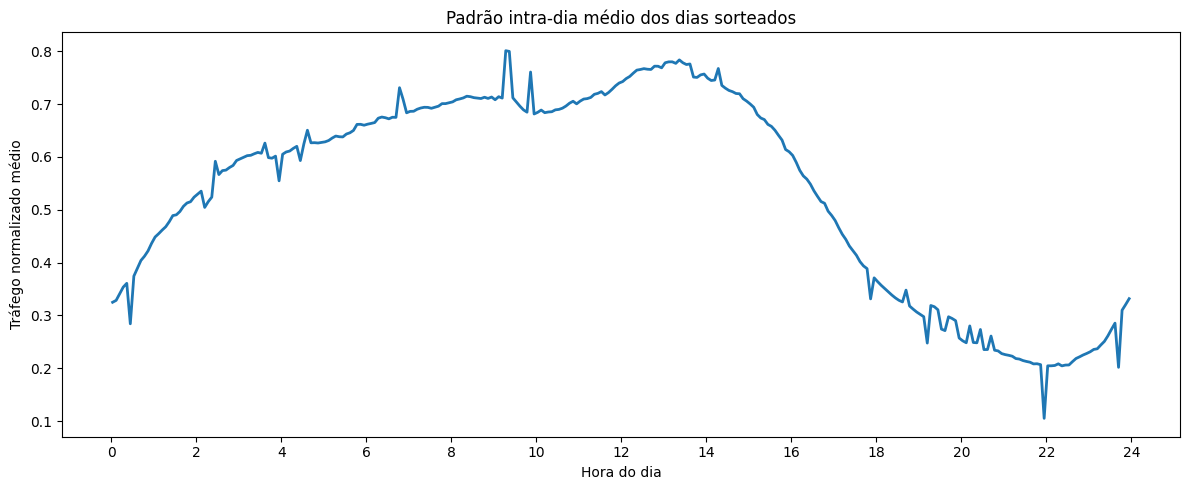

In [24]:
media_intradia = (
    df_amostra.groupby("hora_decimal")["total_norm"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(media_intradia["hora_decimal"], media_intradia["total_norm"], linewidth=2)
plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado médio")
plt.title("Padrão intra-dia médio dos dias sorteados")
plt.xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# criar variáveis
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos (288 pontos)
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# -------- NORMALIZAÇÃO POR DIA --------
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

# -------- AGREGAÇÃO INTRA-DIA --------
intradia_stats = (
    df_intradia.groupby("hora_decimal")["total_norm"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# intervalo de confiança 95%
intradia_stats["ci_lower"] = intradia_stats["mean"] - 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

intradia_stats["ci_upper"] = intradia_stats["mean"] + 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

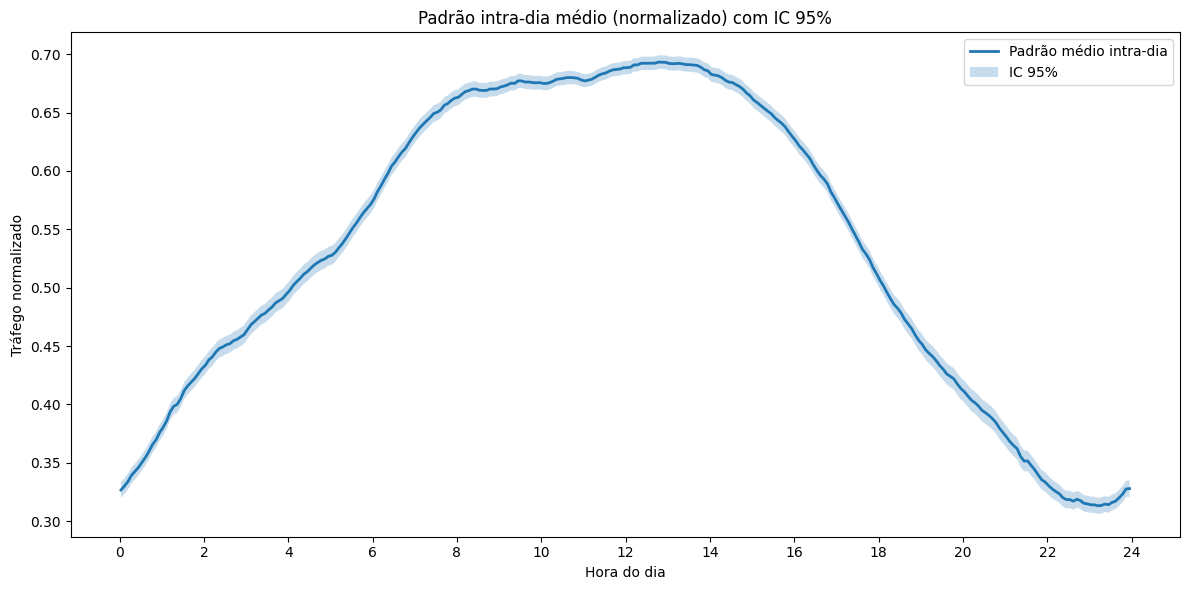

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    intradia_stats["hora_decimal"],
    intradia_stats["mean"],
    label="Padrão médio intra-dia",
    linewidth=2
)

plt.fill_between(
    intradia_stats["hora_decimal"],
    intradia_stats["ci_lower"],
    intradia_stats["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia médio (normalizado) com IC 95%")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# variáveis auxiliares
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["year"] = df_intradia["datahora"].dt.year
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index
df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# normalização por dia
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

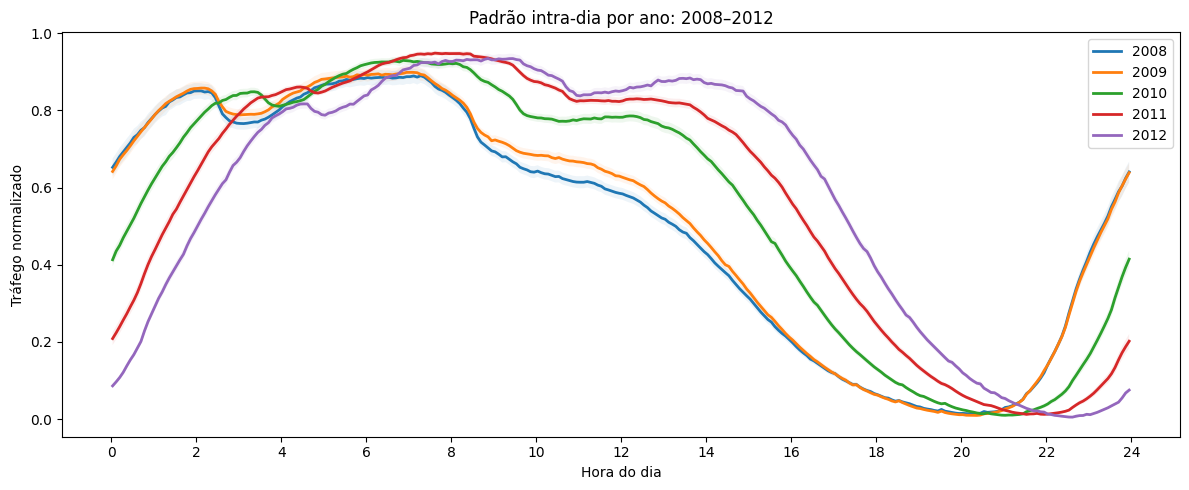

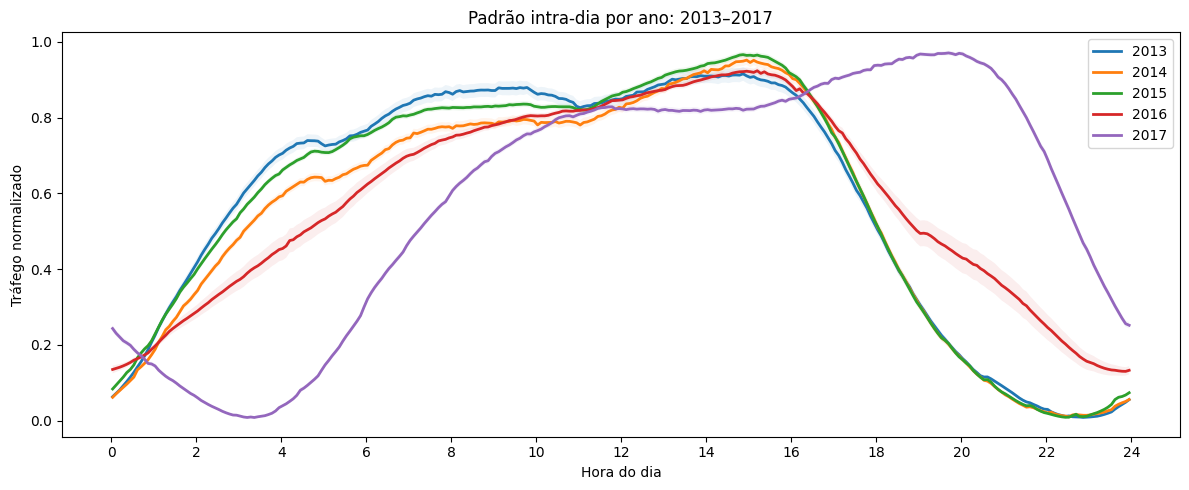

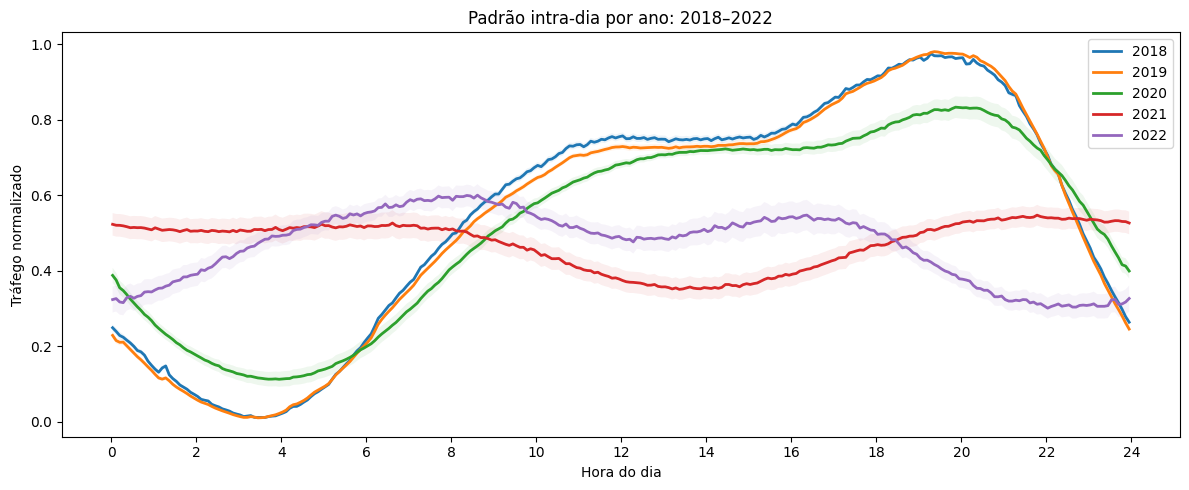

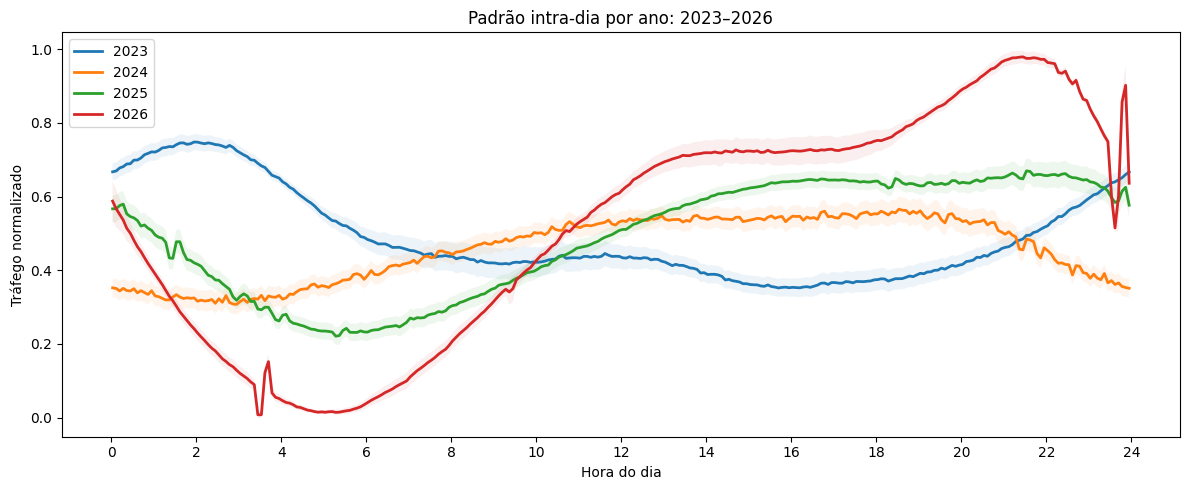

In [28]:
anos = sorted(df_intradia["year"].unique())


blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(12, 5))

    for ano in bloco:
        df_ano = df_intradia[df_intradia["year"] == ano]

        stats = (
            df_ano.groupby("hora_decimal")["total_norm"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        # IC
        stats["ci_lower"] = stats["mean"] - 1.96 * (stats["std"] / np.sqrt(stats["count"]))
        stats["ci_upper"] = stats["mean"] + 1.96 * (stats["std"] / np.sqrt(stats["count"]))

        # linha principal
        plt.plot(
            stats["hora_decimal"],
            stats["mean"],
            label=str(ano),
            linewidth=2
        )

        # IC (opcional mais leve)
        plt.fill_between(
            stats["hora_decimal"],
            stats["ci_lower"],
            stats["ci_upper"],
            alpha=0.08
        )

    plt.xlabel("Hora do dia")
    plt.ylabel("Tráfego normalizado")
    plt.title(f"Padrão intra-dia por ano: {bloco[0]}–{bloco[-1]}")
    plt.xticks(range(0, 25, 2))
    plt.legend()
    plt.tight_layout()
    plt.show()

# Interpretação dos padrões intra-diários

## Evolução do comportamento ao longo do tempo

A análise dos perfis intra-diários revela uma transformação significativa no comportamento do tráfego agregado do IX ao longo dos anos.

### 2008–2012: padrão concentrado e antecipado

Nos anos iniciais, observa-se:

- pico de tráfego nas primeiras horas do dia (aproximadamente entre 6h e 8h);
- queda progressiva ao longo do dia;
- valores mínimos durante a noite.

Esse comportamento é consistente com um padrão de uso predominantemente corporativo, no qual o tráfego está associado a atividades em horário comercial.



### 2013–2017: período de transição

Nesse intervalo, verifica-se:

- deslocamento gradual do pico para o meio do dia;
- aumento da largura da curva de tráfego;
- redução da diferença entre períodos de alta e baixa utilização.

Esse padrão sugere uma transição no perfil de uso da rede, possivelmente associada à expansão do acesso residencial e ao aumento do consumo de conteúdo online.



### 2018–2022: predominância de consumo digital

A partir de 2018, observa-se uma mudança mais acentuada:

- pico de tráfego deslocado para o período noturno (aproximadamente entre 18h e 21h);
- curva mais "achatada", indicando uso mais distribuído ao longo do dia;
- menor variação relativa entre diferentes horários.

Esse comportamento é compatível com o crescimento de aplicações como streaming, redes sociais e uso intensivo da internet em dispositivos móveis.



### 2023–2026: uso contínuo da rede

Nos anos mais recentes:

- o tráfego apresenta maior uniformidade ao longo do dia;
- a diferença entre períodos de pico e vale é reduzida;
- o sistema opera próximo de níveis elevados durante a maior parte do tempo.

Esse padrão indica que a internet passou a ser utilizada como infraestrutura contínua, e não mais apenas em horários específicos.



## Mudança estrutural no perfil de uso

De forma geral, os resultados evidenciam uma mudança estrutural no comportamento da rede:

- inicialmente dominada por uso corporativo;
- posteriormente caracterizada por uma fase de transição;
- e, por fim, marcada por consumo massivo e contínuo de conteúdo digital.

Essa transformação reflete mudanças tecnológicas e sociais, incluindo maior penetração da internet, crescimento do consumo de mídia online e alterações nos hábitos dos usuários.



## Estabilidade do formato intra-diário

Apesar da evolução observada, nota-se que:

- o padrão intra-diário mantém uma forma consistente;
- o que se altera ao longo do tempo é principalmente o nível (escala) e o posicionamento do pico.

Isso sugere que o sistema apresenta:

- invariância de forma (shape);
- crescimento de escala (level).



A análise intra-diária mostra que:

- o comportamento do tráfego evoluiu significativamente ao longo dos anos;
- o pico de utilização foi deslocado para períodos mais tardios;
- o uso da rede tornou-se mais contínuo e distribuído ao longo do dia.

Esses resultados são consistentes com a transformação da internet em uma infraestrutura essencial para múltiplos tipos de uso, incluindo entretenimento, comunicação e trabalho remoto.

# Próximos passos

Como continuidade desta análise exploratória, algumas extensões podem aprofundar a compreensão dos padrões observados:

- realização de comparações formais entre períodos, por meio de testes estatísticos ou modelos apropriados, para avaliar a significância das diferenças identificadas;

- decomposição da série temporal em componentes de tendência, sazonalidade e resíduo, permitindo isolar e quantificar esses efeitos;

- aprofundamento da análise intra-semana e intra-dia, buscando caracterizar com maior granularidade os padrões de uso;

- identificação de possíveis pontos de mudança estrutural na série, para investigar alterações no comportamento ao longo do tempo;

- avaliação e tratamento de valores atípicos ou suspeitos, de modo a garantir a robustez das conclusões.

# Conclusões preliminares

Com base nos dados filtrados por completude e analisados apenas em termos de tráfego total, é possível observar:

1. crescimento estrutural do tráfego ao longo do tempo;
2. diferenças relevantes entre anos no nível médio de tráfego;
3. utilidade da média diária para reduzir ruído e destacar tendência;
4. presença de variabilidade intra-dia, resumida pelo intervalo de confiança;
5. indícios de variação intra-anual em diferentes períodos;
6. possibilidade de mudança estrutural no padrão semanal, comparando dias úteis e fim de semana.